In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

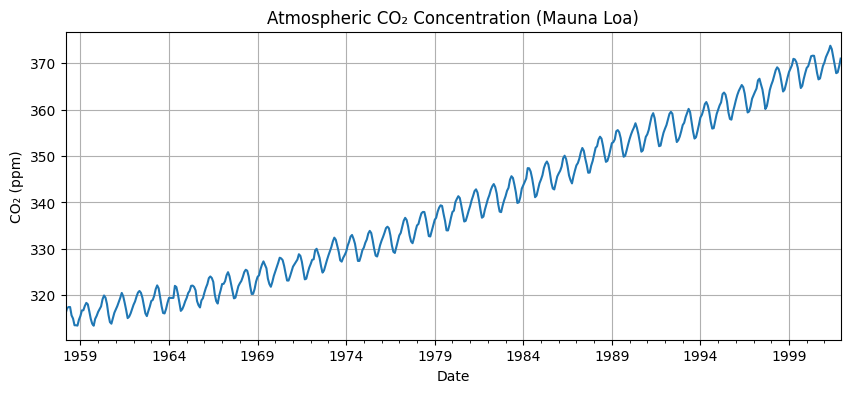

In [2]:

co2_data = sm.datasets.co2.load_pandas().data
co2_monthly = co2_data.resample("MS").mean().ffill()

# Plot complete series
ax = co2_monthly["co2"].plot(
    title="Atmospheric CO₂ Concentration (Mauna Loa)",
    ylabel="CO₂ (ppm)",
    xlabel="Date",
    grid=True,
)
plt.show()

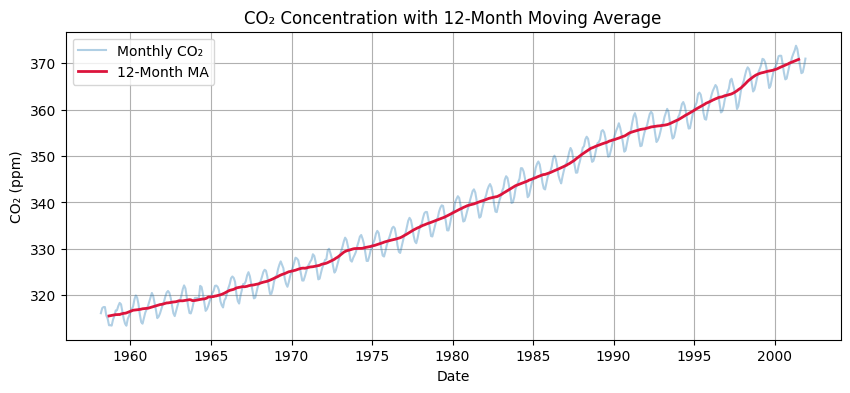

In [3]:

co2_monthly["12MA"] = co2_monthly["co2"].rolling(window=12, center=True).mean()

# Plot raw series against the 12-month moving average
plt.figure()
plt.plot(co2_monthly["co2"], alpha=0.35, label="Monthly CO₂")
plt.plot(
    co2_monthly["12MA"], color="crimson", linewidth=2, label="12-Month MA"
)
plt.title("CO₂ Concentration with 12-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.grid(True)
plt.show()

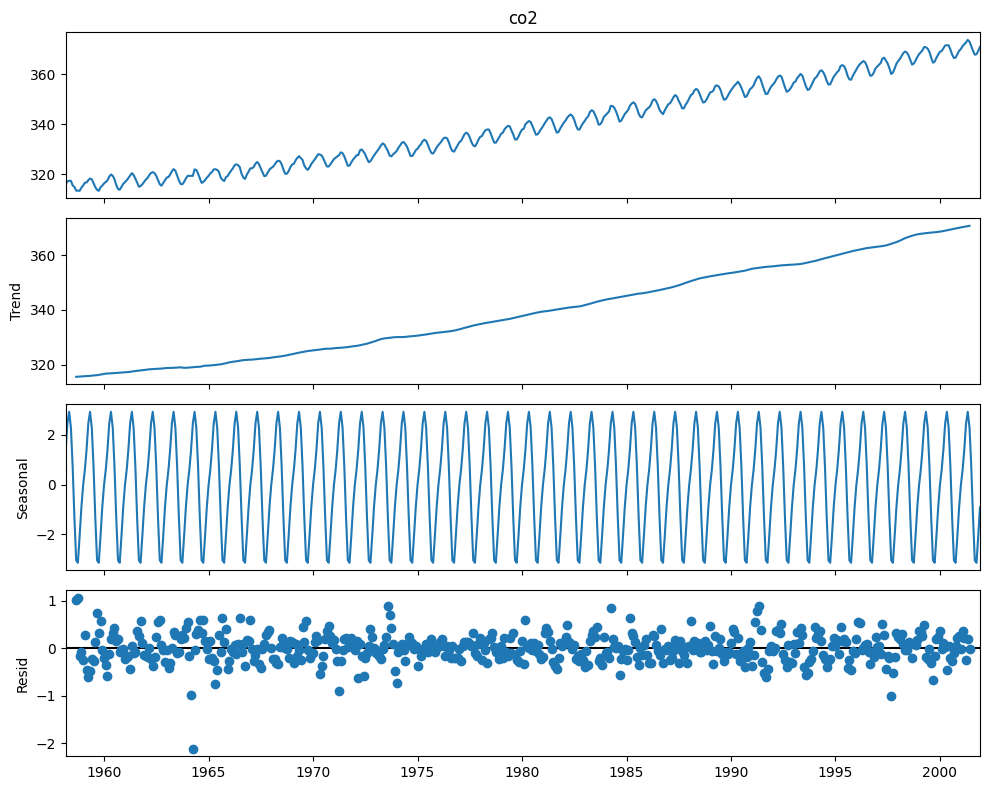

In [4]:

decomposition = sm.tsa.seasonal_decompose(
    co2_monthly["co2"], model="additive", period=12
)


fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [5]:

print("--- TIME SERIES DECOMPOSITION FINDINGS ---")
print(
    f"1. Long-Term Trend : Rises from ~{co2_monthly['co2'].iloc[0]:.1f} ppm to ~{co2_monthly['co2'].iloc[-1]:.1f} ppm."
)
print(
    "2. Seasonal Pattern : ~6 ppm annual peak-to-trough swing (Peaks in May, Troughs in Oct)."
)
print(
    "3. Residuals        : Random noise centered at 0 ppm with minimal variance."
)

--- TIME SERIES DECOMPOSITION FINDINGS ---
1. Long-Term Trend : Rises from ~316.1 ppm to ~371.0 ppm.
2. Seasonal Pattern : ~6 ppm annual peak-to-trough swing (Peaks in May, Troughs in Oct).
3. Residuals        : Random noise centered at 0 ppm with minimal variance.


Average Seasonal Deviation (ppm from trend):


,seasonal
January,-0.012585
February,0.622580
March,1.396790
April,2.464765
May,2.930017
June,2.286460
July,0.749015
August,-1.312790
September,-3.036605
October,-3.136581


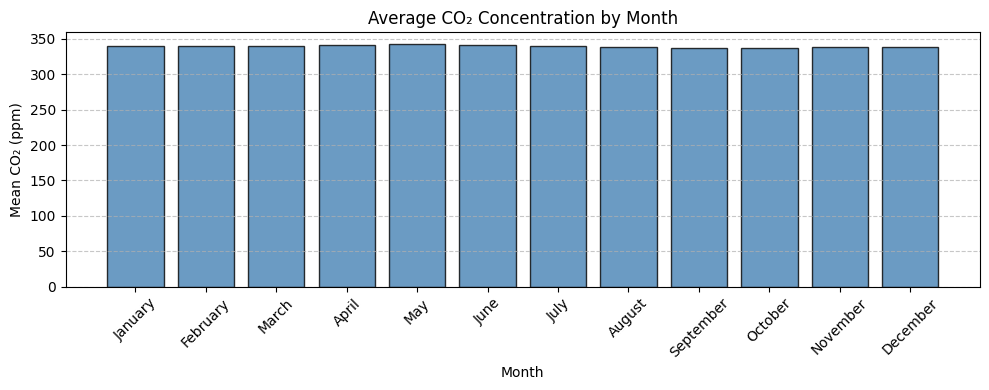

In [6]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# Calculate mean seasonal component per calendar month
avg_seasonal = decomposition.seasonal.groupby(
    co2_monthly.index.month_name()
).mean()[month_order]

print("Average Seasonal Deviation (ppm from trend):")
display(pd.DataFrame(avg_seasonal))

# Plot mean raw CO2 concentration by month
raw_monthly_mean = co2_monthly.groupby(co2_monthly.index.month_name())[
    "co2"
].mean()[month_order]

plt.figure()
plt.bar(
    month_order,
    raw_monthly_mean,
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
)
plt.title("Average CO₂ Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Mean CO₂ (ppm)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()